# Linear Image Denoising

Study denoising as a tradeoff between suppressing random fluctuations and retaining useful detail. Compare linear filters in the Fourier domain and relate their frequency responses to the reconstructed images.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline

This numerical tour introduces basic image denoising methods.


$\newcommand{\dotp}[2]{\langle #1, #2 \rangle}$
$\newcommand{\enscond}[2]{\lbrace #1, #2 \rbrace}$
$\newcommand{\pd}[2]{ \frac{ \partial #1}{\partial #2} }$
$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$
$\newcommand{\umax}[1]{\underset{#1}{\max}\;}$
$\newcommand{\uargmin}[1]{\underset{#1}{argmin}\;}$
$\newcommand{\norm}[1]{\|#1\|}$
$\newcommand{\abs}[1]{\left|#1\right|}$
$\newcommand{\choice}[1]{ \left\{  \begin{array}{l} #1 \end{array} \right. }$
$\newcommand{\pa}[1]{\left(#1\right)}$
$\newcommand{\diag}[1]{{diag}\left( #1 \right)}$
$\newcommand{\qandq}{\quad\text{and}\quad}$
$\newcommand{\qwhereq}{\quad\text{where}\quad}$
$\newcommand{\qifq}{ \quad \text{if} \quad }$
$\newcommand{\qarrq}{ \quad \Longrightarrow \quad }$
$\newcommand{\ZZ}{\mathbb{Z}}$
$\newcommand{\CC}{\mathbb{C}}$
$\newcommand{\RR}{\mathbb{R}}$
$\newcommand{\EE}{\mathbb{E}}$
$\newcommand{\Zz}{\mathcal{Z}}$
$\newcommand{\Ww}{\mathcal{W}}$
$\newcommand{\Vv}{\mathcal{V}}$
$\newcommand{\Nn}{\mathcal{N}}$
$\newcommand{\NN}{\mathcal{N}}$
$\newcommand{\Hh}{\mathcal{H}}$
$\newcommand{\Bb}{\mathcal{B}}$
$\newcommand{\Ee}{\mathcal{E}}$
$\newcommand{\Cc}{\mathcal{C}}$
$\newcommand{\Gg}{\mathcal{G}}$
$\newcommand{\Ss}{\mathcal{S}}$
$\newcommand{\Pp}{\mathcal{P}}$
$\newcommand{\Ff}{\mathcal{F}}$
$\newcommand{\Xx}{\mathcal{X}}$
$\newcommand{\Mm}{\mathcal{M}}$
$\newcommand{\Ii}{\mathcal{I}}$
$\newcommand{\Dd}{\mathcal{D}}$
$\newcommand{\Ll}{\mathcal{L}}$
$\newcommand{\Tt}{\mathcal{T}}$
$\newcommand{\si}{\sigma}$
$\newcommand{\al}{\alpha}$
$\newcommand{\la}{\lambda}$
$\newcommand{\ga}{\gamma}$
$\newcommand{\Ga}{\Gamma}$
$\newcommand{\La}{\Lambda}$
$\newcommand{\Si}{\Sigma}$
$\newcommand{\be}{\beta}$
$\newcommand{\de}{\delta}$
$\newcommand{\De}{\Delta}$
$\newcommand{\phi}{\varphi}$
$\newcommand{\th}{\theta}$
$\newcommand{\om}{\omega}$
$\newcommand{\Om}{\Omega}$


In [2]:
from nt_toolbox.general import clamp
from nt_toolbox.signal import cconv, imageplot, load_image
import numpy as np
import matplotlib.pyplot as plt
from numpy import (
    abs,
    arange,
    argmin,
    concatenate,
    exp,
    linspace,
    meshgrid,
    random,
    real,
    sum,
    transpose,
    zeros,
)
from matplotlib.pyplot import axis, clf, matplotlib, plot, subplot, title
from numpy.linalg import norm
from numpy.fft import fft2, fftshift, ifft2

%matplotlib inline

## Noisy Image Formation


In these numerical tour, we simulate noisy acquisition by adding some
white noise (each pixel is corrupted by adding an independant Gaussian
variable).


This is useful to test in an oracle maner the performance of our methods.


Size $N = n \times n$ of the image.


In [3]:
n = 256
N = n**2

We load a clean image $x_0 \in \RR^N$.


In [4]:
name = "nt_toolbox/data/flowers.png"
x0 = load_image(name, n)

Display the clean image.


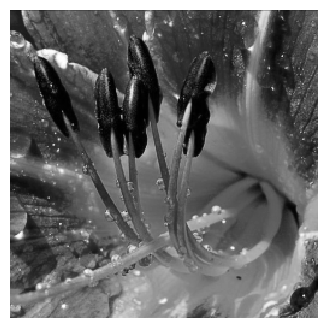

In [5]:
imageplot(x0)

Variance of the noise.


In [6]:
sigma = 0.08

We add some noise to it to obtain the noisy signal $y = x_0 + w$.
Here $w$ is a realization of a Gaussian white noise of variance
$\si^2$.


In [7]:
y = x0 + sigma * random.standard_normal(x0.shape)

Display the noisy image.


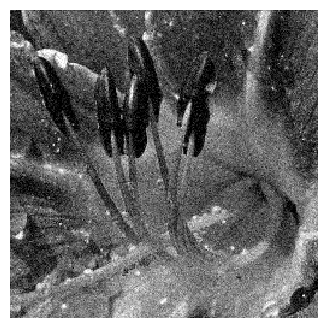

In [8]:
imageplot(clamp(y))

## Linear Image Denoising


We consider a noising estimator $x \in \RR^N$ of $x_0$ that only
depends on the observation $y$. Mathematically speaking, it is thus a
random vector that depends on the noise $w$.


A translation invariant linear denoising is necessarely a convolution
with a kernel $h$
$$ x = x_0 \star h $$
where the periodic convolution between two 2-D arrays is defined as
$$ (a \star b)_i = \sum_j a(j) b(i-j). $$


It can be computed over the Fourier domain as
$$ \forall \om, \quad \hat x(\om) = \hat x_0(\om) \hat h(\om). $$


In [9]:
cconv = lambda a, b: real(ifft2(fft2(a) * fft2(b)))

We use here a Gaussian fitler $h$ parameterized by
the bandwith $\mu$.


In [10]:
normalize = lambda h: h / sum(h.flatten())
t = transpose(concatenate((arange(0, n / 2), arange(-n / 2, 0))))
[Y, X] = meshgrid(t, t)
h = lambda mu: normalize(exp(-(X**2 + Y**2) / (2 * mu**2)))

Display the filter $h$ and its Fourier transform.


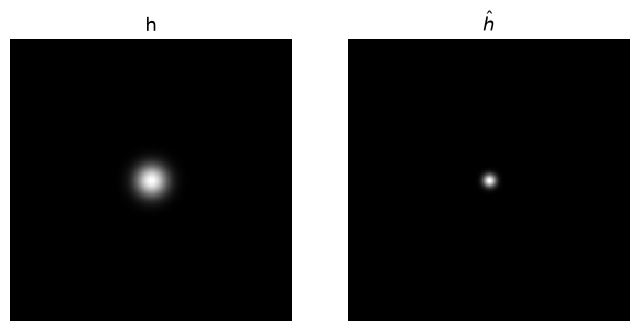

In [11]:
mu = 10
subplot(1, 2, 1)
imageplot(fftshift(h(mu)))
title("h")
subplot(1, 2, 2)
imageplot(fftshift(real(fft2(h(mu)))))
title(r"$\hat h$");

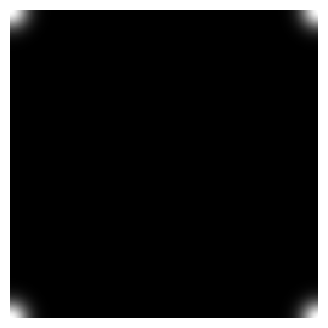

In [12]:
imageplot(h(mu))

Shortcut for the convolution with $h$.


In [13]:
denoise = lambda x, mu: cconv(h(mu), x)

Display a denoised signal.


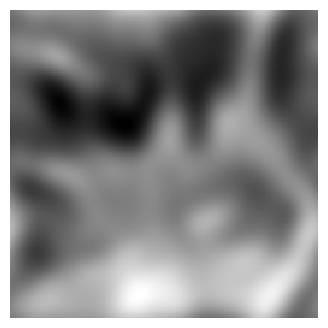

In [14]:
imageplot(denoise(y, mu))

**Worked example 1:** Display a denoised signal for several values of $\mu$.


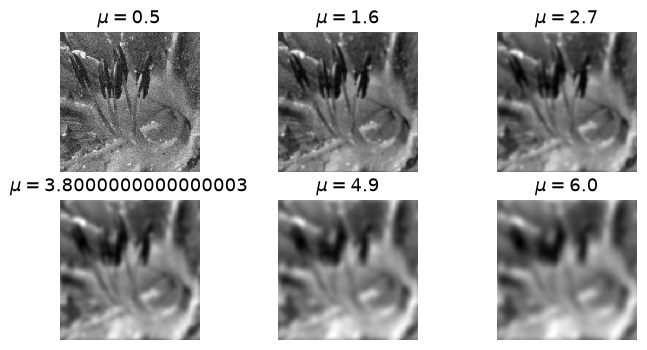

In [15]:
mu_list = linspace(0.5, 6, 6)
clf
for i in arange(0, len(mu_list)):
    mu = mu_list[i]
    subplot(2, 3, i + 1)
    imageplot(denoise(y, mu))
    title(r"$\mu=" + str(mu) + "$")

**Worked example 2:** Display the evolution of the oracle denoising error
$ \norm{y-x_0} $ as a function of $\mu$.
Set $\mu$ to the value of the optimal parameter.


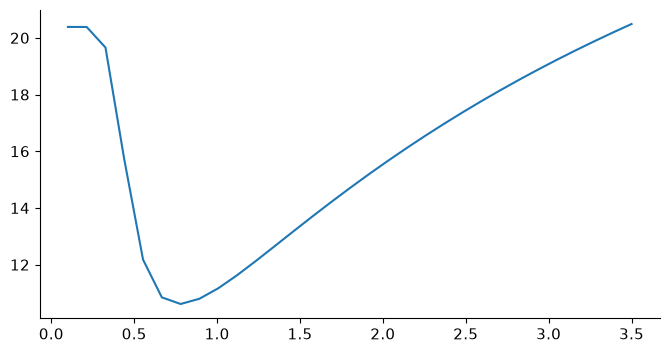

In [16]:
mulist = linspace(0.1, 3.5, 31)
# err = arrayfun(@(mu)norm(x0-denoise(y,mu), 'fro' ), mulist);
err = zeros([len(mulist), 1])
for i in arange(0, len(mulist)):
    mu = mulist[i]
    err[i] = norm(x0 - denoise(y, mu))
clf
(h1,) = plot(mulist, err)
axis("tight")
# set_label('\mu', '|y-x_0|');
# retrieve the best denoising result
i = argmin(err)
mu = mulist[i];

Display the results.


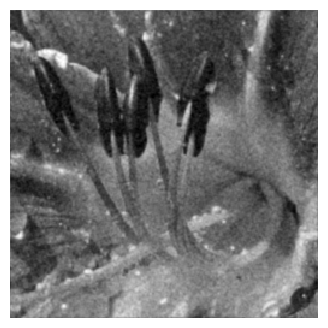

In [17]:
imageplot(denoise(y, mu))

## Wiener Filtering


We suppose here that $x_0$ is a realization of a random vector $x_0$,
whose distribution is Gaussian with a stationary covariance $c$,
and we denote $P_{X_0}(\om) = \hat c(\om)$ the power-spectrum of
$x_0$.


Recall that $w$ is a realization of a random vector $W$
distributed according to $\Nn(0,\si^2 \text{Id})$.


The (oracle) optimal filter minimizes the risk
$$ R(h) = \EE_{W,X_0}( \norm{ X_0 - h \star (X_0 + W) }^2 ). $$


One can show that the solution of this problem, the so-called Wiener filter,
is defined as
$$ \forall \om, \quad \hat h(\om) = \frac{ P_{X_0}(\om) }{ P_{X_0}(\om) + \si^2 }. $$


We estimate $ P_{X_0} $ using the periodogram associated to the
realization $x_0$, i.e.
$$ P_{X_0} \approx \frac{1}{N}\abs{\hat x_0}^2. $$


In [18]:
P = 1 / N * (abs(fft2(x0)) ** 2)

Compute the approximate Wiener filter.


In [19]:
h_w = real(ifft2(P / (P + sigma**2)))

Note that this is a theoretical filter, because in practice one does not
have access to $x_0$. Display it.


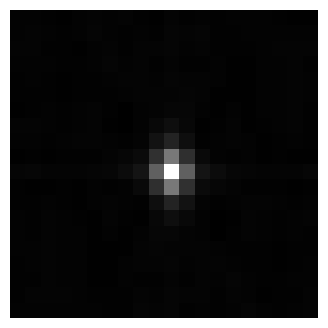

In [20]:
u = fftshift(h_w)
imageplot(u[n // 2 - 10 : n // 2 + 10, n // 2 - 10 : n // 2 + 10])

Display the denoising result.


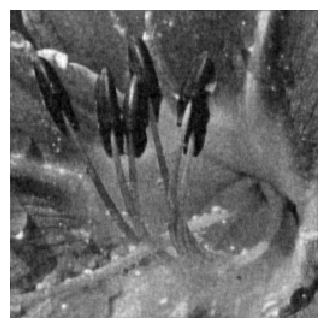

In [21]:
imageplot(cconv(y, h_w))

Note that this denoising is not very efficient, because the hypothesis of
stationarity of $X_0$ is not realistic for such piecewise-regular
signal.


## References and further reading

- Antoni Buades, Bartomeu Coll, and Jean-Michel Morel. [A Review of Image Denoising Algorithms, with a New One](https://doi.org/10.1137/040616024). 2005, Multiscale Modeling & Simulation 4(2), 490–530. Comparison of local, transform, and nonlocal denoising models.

- David L. Donoho. [De-noising by Soft-Thresholding](https://doi.org/10.1109/18.382009). 1995, IEEE Transactions on Information Theory 41(3), 613–627. Why shrinkage of wavelet coefficients suppresses noise.

- Charles M. Stein. [Estimation of the Mean of a Multivariate Normal Distribution](https://doi.org/10.1214/aos/1176345632). 1981, Annals of Statistics 9(6), 1135–1151. Unbiased risk estimation for Gaussian observations.

- Leonid Rudin, Stanley Osher, and Emad Fatemi. [Nonlinear Total Variation Based Noise Removal Algorithms](https://doi.org/10.1016/0167-2789(92)90242-F). 1992, Physica D 60, 259–268. The foundational total-variation image restoration model.

- Stéphane Mallat. [A Wavelet Tour of Signal Processing: The Sparse Way](https://www.di.ens.fr/~mallat/biblio.html). 2009, 3rd ed., Academic Press. Multiresolution analysis, sparse approximation, and wavelet algorithms.

- Gabriel Peyré. [Advanced Signal, Image and Surface Processing](https://www.numerical-tours.com/book/AdvancedSignalProcessing.pdf). 2010, course notes. A mathematical companion to the Numerical Tours.
